In [12]:
from joblib import dump,load
import os

In [13]:
def load_joblib(filepath):
    """Load object using joblib"""
    try:
        if not os.path.exists(filepath):
            print(f"File {filepath} does not exist.")
            return None
        return load(filepath)
    except Exception as e:
        print(f"Error loading joblib file: {e}")
        return None

In [14]:
joblib_path = os.path.join(os.path.dirname(os.getcwd()), 'joblib_files')

In [15]:
# Load the files
google_pro = load_joblib(os.path.join(joblib_path, 'google_pro.joblib'))
trust_pro = load_joblib(os.path.join(joblib_path, 'trust_pro.joblib'))

##### Google Reviews Frequency Distribution

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize,RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from nltk.stem.porter import PorterStemmer
import gdown
import os
import re

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'good'),
  Text(1, 0, 'great gym'),
  Text(2, 0, 'good gym'),
  Text(3, 0, 'excellent'),
  Text(4, 0, 'nice gym'),
  Text(5, 0, 'great'),
  Text(6, 0, 'nice'),
  Text(7, 0, 'ok'),
  Text(8, 0, 'great class'),
  Text(9, 0, 'nice place')])

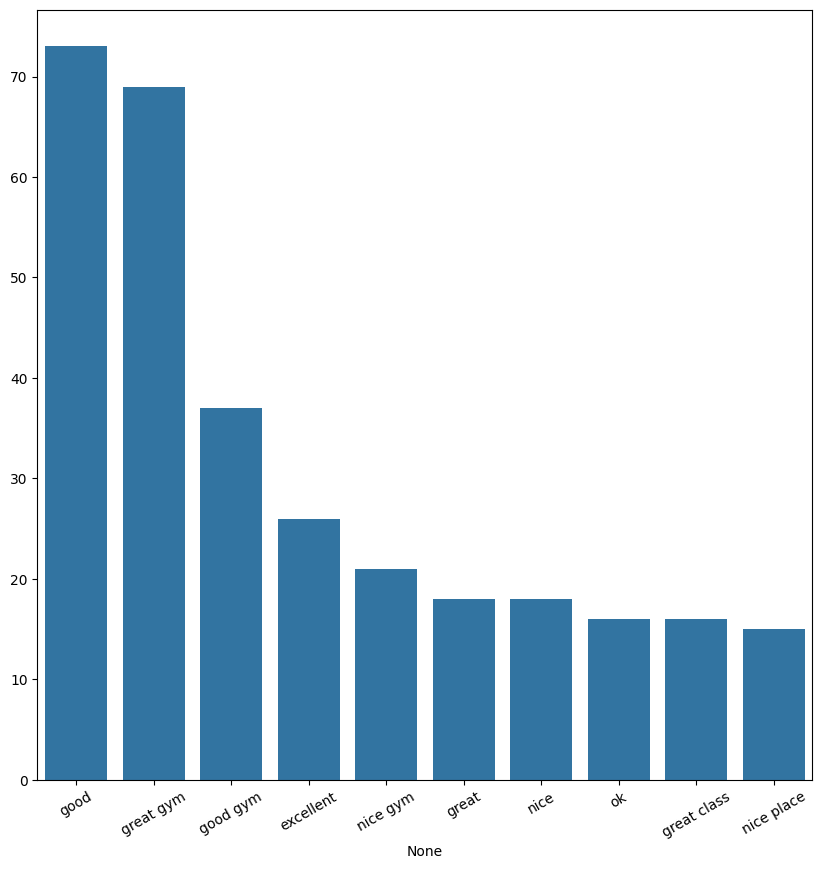

In [20]:
gdist = FreqDist(google_pro).most_common(10)

# Convert to Pandas Series for easier plotting

gdist = pd.Series(dict(gdist))

fig, ax = plt.subplots(figsize=(10,10))

# Seaborn plotting

g_plot = sns.barplot(x=gdist.index, y=gdist.values, ax=ax)

plt.xticks(rotation = 30)

##### Trustpilot Reviews: Frequency Distribution

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'easy join'),
  Text(1, 0, 'quick easy'),
  Text(2, 0, 'good gym'),
  Text(3, 0, 'easy sign'),
  Text(4, 0, 'easy'),
  Text(5, 0, 'friendly staff'),
  Text(6, 0, 'great experience'),
  Text(7, 0, 'easy quick'),
  Text(8, 0, 'excellent gym'),
  Text(9, 0, 'good')])

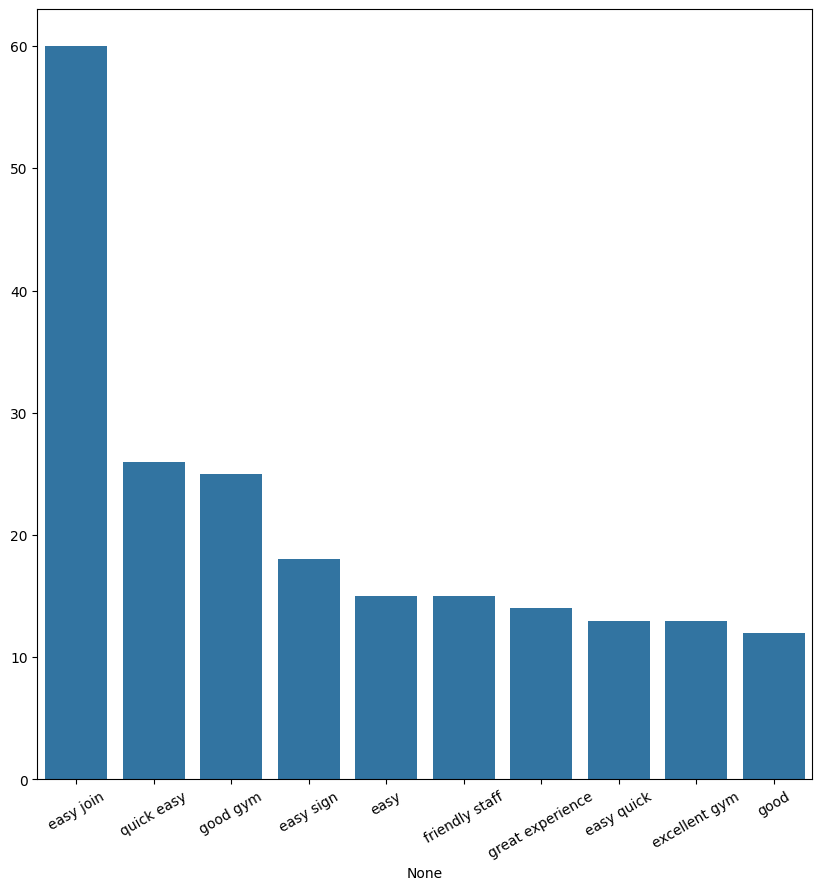

In [21]:
tdist = FreqDist(trust_pro).most_common(10)

# Convert to Pandas Series for easier plotting

tdist = pd.Series(dict(tdist))

fig, ax = plt.subplots(figsize=(10,10))

# Seaborn plotting

t_plot = sns.barplot(x=tdist.index, y=tdist.values, ax=ax)

plt.xticks(rotation = 30)

## WordCloud

In [23]:
from PIL import Image
from wordcloud import WordCloud

In [31]:
root_dir = os.path.dirname(os.getcwd())  # Go up one level from notebook directory
g_logo_path = os.path.join(root_dir, 'google_logo.png')

In [32]:
google_mask = np.array(Image.open(g_logo_path)).resize((800, 500))


google_mask_gray = np.array(Image.open(g_logo_path).convert("L"))

# Threshold the image to create a binary mask (black and white)
google_mask = np.where(google_mask_gray > 200, 255, 0)  # Adjust threshold value if needed


google_mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

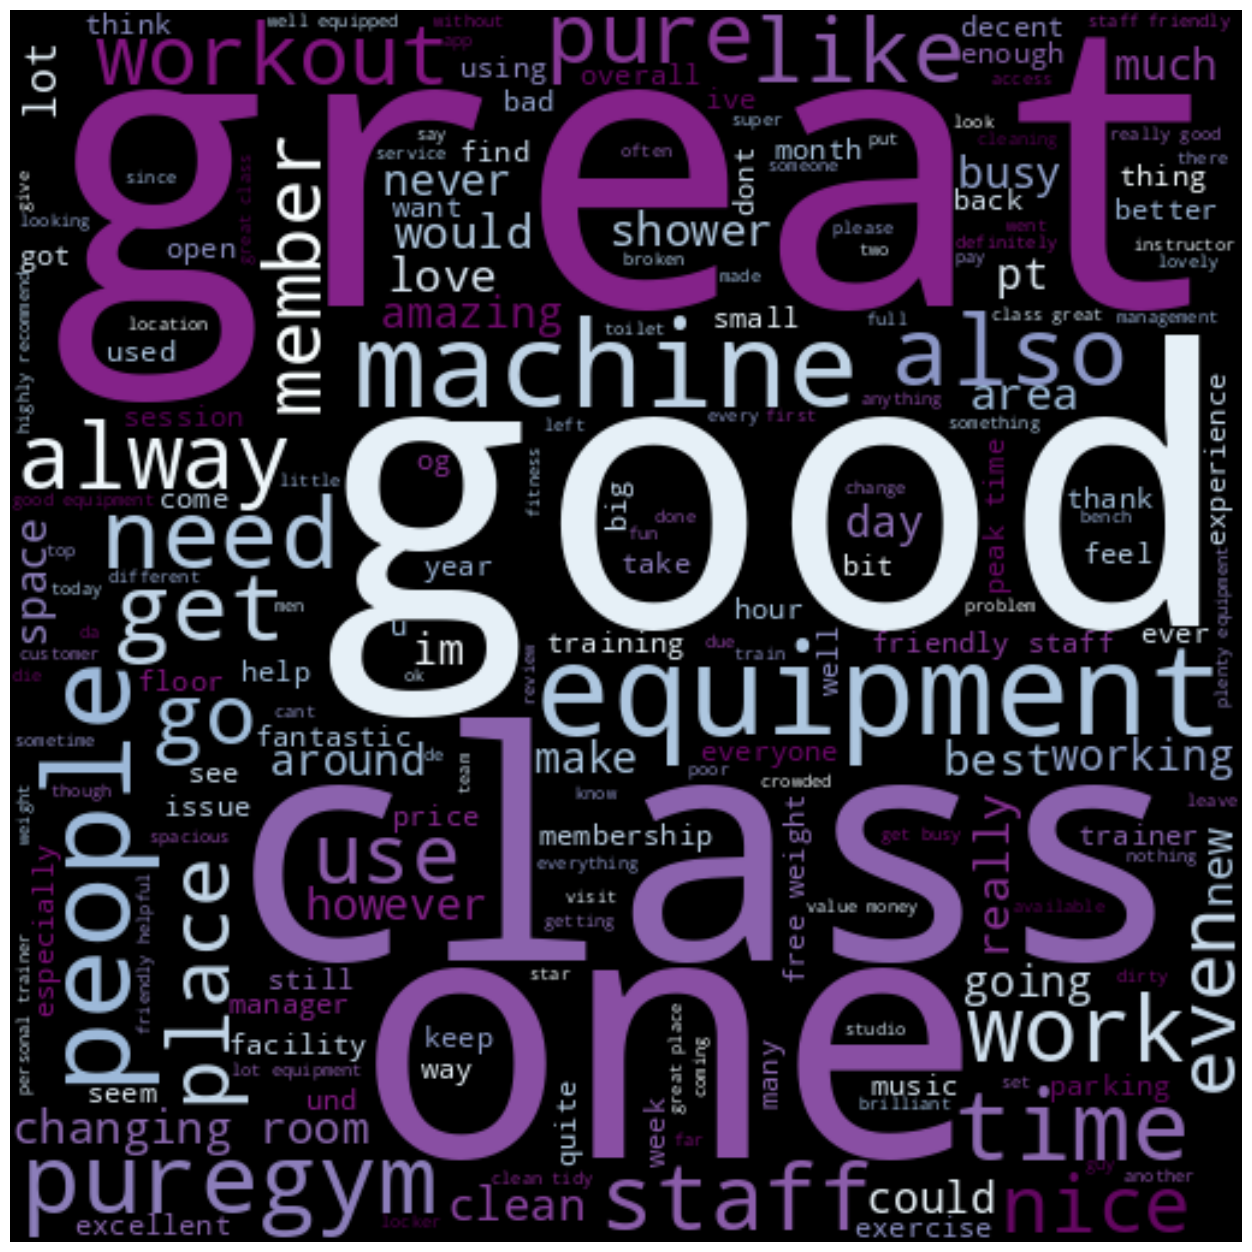

In [33]:
google_wc = WordCloud(background_color='black',mask= google_mask,contour_width=2,contour_color= 'black',colormap= 'BuPu_r',stopwords = ['gym'],width = 800, height = 500).generate(' '.join(google_pro)) #Had to remove Gym because it was not giving much information but we see that it probably occured a lot of times in these reviews

plt.figure(figsize=[16,16])
plt.tight_layout()
plt.imshow(google_wc, interpolation="bilinear")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(999.5), np.float64(799.5), np.float64(-0.5))

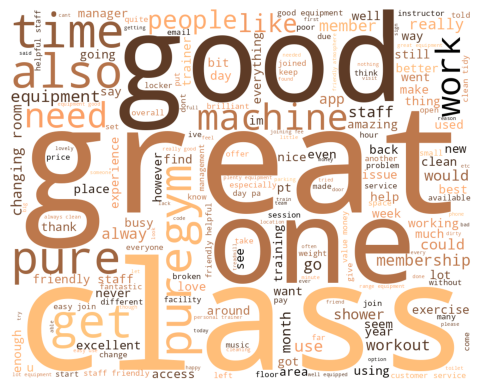

In [34]:
trust_wc = WordCloud(background_color='white', colormap = 'copper',stopwords = ['gym'],width = 1000, height = 800).generate(' '.join(trust_pro)) #Had to remove Gym because it was not giving much information but we see that it probably occured a lot of times in these reviews

plt.imshow(trust_wc)
plt.axis("off")

## Negative Reviews

In [ ]:
df_gneg = df_google.loc[df_google['Overall Score']<3]
df_tneg = df_trust.loc[df_trust['Review Stars']<3]

